In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

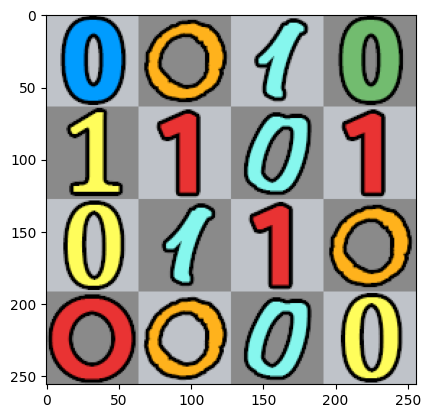

(256, 256)


In [20]:
train_df= pd.read_csv('train.csv')
test_df= pd.read_csv('test.csv')

plt.imshow(Image.open(train_df.iloc[0]['id']))
plt.show()
print(Image.open(train_df.iloc[0]['id']).size)

In [21]:
def split_into_cells(img):
    cells = []
    for row in range(4):
        for col in range(4):
            up= row* 64
            left= col* 64
            right= left+ 64
            down= up+ 64
            cells.append(img.crop((left, up, right, down)))
    return cells

In [22]:
from torch.utils.data import Dataset , DataLoader
from torchvision import transforms
class OneCellDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        
        img= Image.open(self.df.iloc[idx]['id'])
        label= self.df.iloc[idx]['type']

        cell = split_into_cells(img)[0].convert('L')

        if self.transform:
            cell = self.transform(cell)

        return cell, label

train_transforms= transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transforms= transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

train_dataset= OneCellDataset('train.csv', transform=train_transforms)

train_loader= DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(torch.nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(6, 10, 5)

        self._to_linear= None
        self._get_conv_output()
        
        self.fc1= nn.Linear(self._to_linear, 64)
        self.fc2= nn.Linear(64, 32)
        self.fc3= nn.Linear(32, 2)
    
    def _get_conv_output(self):
        x= torch.randn(1, 1, 32, 32)
        x= self.pool(F.relu(self.conv1(x)))
        x= self.pool(F.relu(self.conv2(x)))

        self._to_linear= x.numel()

    def forward(self, x):
        x= self.pool(F.relu(self.conv1(x)))
        x= self.pool(F.relu(self.conv2(x)))

        x= torch.flatten(x, 1)

        x= F.relu(self.fc1(x))
        x= F.relu(self.fc2(x))
        x= self.fc3(x)
        return x

In [24]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)

criterion= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(model.parameters(), lr=0.001)

In [25]:
for epoch in range(10):
    running_loss= 0.0
    for images, labels in train_loader:
        images= images.to(device)
        labels= labels.to(device)

        optimizer.zero_grad()

        predictions= model(images)
        loss= criterion(predictions, labels)

        loss.backward()
        optimizer.step()

        running_loss+= loss
    print(f'The loss for epoch:{epoch+1} is {running_loss:.5f}')

        

The loss for epoch:1 is 8.95748
The loss for epoch:2 is 8.35641
The loss for epoch:3 is 6.38140
The loss for epoch:4 is 2.15477
The loss for epoch:5 is 0.18706
The loss for epoch:6 is 0.02559
The loss for epoch:7 is 0.00989
The loss for epoch:8 is 0.00559
The loss for epoch:9 is 0.00469
The loss for epoch:10 is 0.00434


In [26]:
def predict_image(model, img_path, transform, device):
    img= Image.open(img_path).convert('L')
    cells= split_into_cells(img)

    predictions= []

    with torch.no_grad():
        for cell in cells:
            cell= transform(cell)
            cell= torch.unsqueeze(cell, 0).to(device)

            output= model(cell)
            _, pred= torch.max(output, 1)

            predictions.append(pred.item())
    
    return predictions

In [27]:
answer = []

for _, row in test_df.iterrows():
    predictions= predict_image(model= model, img_path= row['id'], transform= test_transforms, device= device)
    answer.append({
        'subtaskID': 1,
        'ID': row['id'],
        'answer': predictions[0]
    })
    binary_str = ''.join(map(str, predictions))
    answer.append({
        'subtaskID': 2,
        'ID': row['id'],
        'answer': int(binary_str, 2) if int(binary_str, 2) < 2**15 else int(binary_str, 2)- 2**16
    })

In [28]:
pd.DataFrame(answer).to_csv("submission.csv", index= False)